ESERCIZIO

Analisi di REcensioni Tecnologiche
Traccia: ti viene fornito un piccolo set di recensioni riguardanti uno smartphone
Estendi la pipeline aggiungendo una lista personalizzata di stopwords che include parole: smartphone telefono cellulare (termini troppo ovvi in questo contesto che inquinerebbero la wordcloud)
Esegui la pipeline completa
Idnetifica 

Esecuzione Pipeline su recensioni tecnologiche...
------------------------------
I 3 lemmi più frequenti sono:
- batteria: 1 volte
- incredibile: 1 volte
- durare: 1 volte
------------------------------


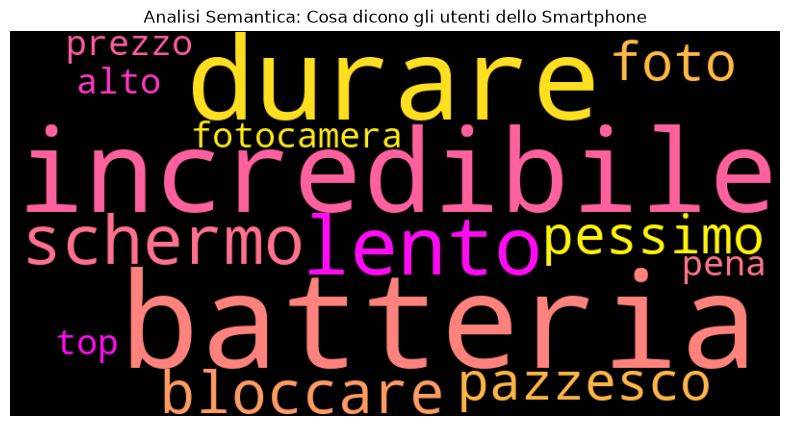

In [1]:
import os
import re
import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# 1. Caricamento modello spaCy
try:
    nlp = spacy.load("it_core_news_sm")
except OSError:
    os.system("python -m spacy download it_core_news_sm")
    nlp = spacy.load("it_core_news_sm")

# 2. Dataset di Recensioni Smartphone
smartphone_reviews = [
    "Questo smartphone ha una batteria incredibile, dura due giorni!",
    "Il telefono è lento, lo schermo si blocca sempre. Pessimo cellulare.",
    "Foto pazzesche con questo smartphone. La fotocamera è il top.",
    "Prezzo troppo alto per questo telefono, non ne vale la pena."
]

def extended_nlp_pipeline(text_data, custom_stops):
    """
    Pipeline con pulizia regex, lemmatizzazione e rimozione di stopwords personalizzate.
    """
    processed_docs = []
    
    # Aggiorniamo le stopwords del modello con la nostra lista
    for word in custom_stops:
        nlp.vocab[word].is_stop = True

    for text in text_data:
        # Pulizia Regex
        text = re.sub(r'<.*?>|https?://\S+', '', text)
        text = re.sub(r'[^a-zA-Zàèìòù\s]', '', text).lower()
        
        doc = nlp(text)
        
        # Estrazione lemmi filtrando stopwords (incluse le personalizzate)
        lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_space]
        processed_docs.append(" ".join(lemmas))
        
    return processed_docs

# 3. Definizione Stopwords Personalizzate
custom_stopwords = ["smartphone", "telefono", "cellulare"]

# 4. Esecuzione Pipeline
print("Esecuzione Pipeline su recensioni tecnologiche...")
cleaned_reviews = extended_nlp_pipeline(smartphone_reviews, custom_stopwords)

# 5. Identificazione dei 3 lemmi più frequenti
all_words = " ".join(cleaned_reviews).split()
word_freq = Counter(all_words)
top_3_lemmas = word_freq.most_common(3)

print("-" * 30)
print(f"I 3 lemmi più frequenti sono:")
for lemma, count in top_3_lemmas:
    print(f"- {lemma}: {count} volte")
print("-" * 30)

# 6. Generazione WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='black',
    colormap='spring'
).generate(" ".join(cleaned_reviews))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Analisi Semantica: Cosa dicono gli utenti dello Smartphone")
plt.show()